### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime


In [149]:
df = pd.read_csv('/content/marketing_campaign.csv', sep="\t")

In [150]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [152]:
print("Income")
print(f"Кількість записів: {len(df.Income)}")
print(f"Пропуски: {df.Income.isna().sum()} ({df.Income.isna().mean():.2%})")
print(f"Унікальних значень: {df.Income.nunique(dropna=True)}")
desc = df.Income.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])
print(desc)


Income
Кількість записів: 2240
Пропуски: 24 (1.07%)
Унікальних значень: 1974
count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
1%         7579.200000
5%        18985.500000
25%       35303.000000
50%       51381.500000
75%       68522.000000
95%       84130.000000
99%       94458.800000
max      666666.000000
Name: Income, dtype: float64


In [153]:
median_income = df["Income"].median()

df["Income"] = df["Income"].fillna(median_income)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Вирішив заповнити пропущені значення медіаною так як є певні екстремальні значення, а медіана в таких випадках залишається стабільною

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [155]:
categorical_cols = ['Education', 'Marital_Status']
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))

In [156]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")
df['Year_Customer'] = df['Dt_Customer'].dt.year
df['Month_Customer'] = df['Dt_Customer'].dt.month
df['Days_Since_Customer'] = (datetime.today() - df['Dt_Customer']).dt.days

In [157]:
df = pd.concat([df.drop(columns=categorical_cols + ['Dt_Customer']), encoded_df], axis=1)

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Year_Birth               2240 non-null   int64  
 2   Income                   2240 non-null   float64
 3   Kidhome                  2240 non-null   int64  
 4   Teenhome                 2240 non-null   int64  
 5   Recency                  2240 non-null   int64  
 6   MntWines                 2240 non-null   int64  
 7   MntFruits                2240 non-null   int64  
 8   MntMeatProducts          2240 non-null   int64  
 9   MntFishProducts          2240 non-null   int64  
 10  MntSweetProducts         2240 non-null   int64  
 11  MntGoldProds             2240 non-null   int64  
 12  NumDealsPurchases        2240 non-null   int64  
 13  NumWebPurchases          2240 non-null   int64  
 14  NumCatalogPurchases     

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [159]:
X = df.drop(columns='ID')

In [160]:
from sklearn.cluster import KMeans
from sklearn import metrics

In [161]:
kmeans = KMeans(n_clusters=3, random_state=17)

kmeans.fit(X)

labels = kmeans.predict(X)

silhouette = metrics.silhouette_score(X, labels, metric='euclidean')

print(silhouette)

0.5981910988432605


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [162]:
import plotly.express as px

In [163]:
px.scatter_3d(X, x='Income', y='NumWebPurchases', z='NumWebPurchases', color=labels)

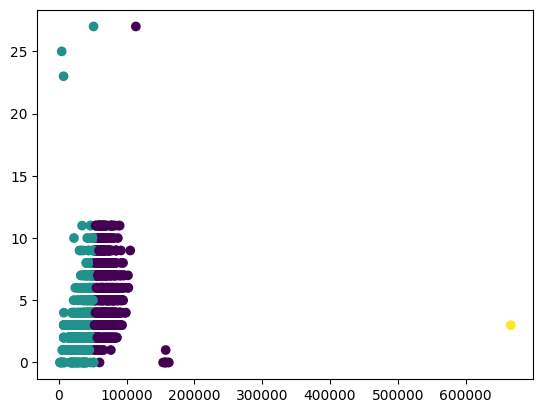

In [164]:
plt.scatter(X['Income'], X['NumWebPurchases'], c=labels)
plt.show()

Кластери мають певний сенс, видно, що алгоритм розбив покупців згідно їх доходу, але є один викид, який дуже далеко від усіх інших значень і алгоритм виділив його в окремий кластер

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [165]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [166]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [167]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [168]:
kmeans = KMeans(n_clusters=3, random_state=17)

kmeans.fit(X_scaled)

labels = kmeans.predict(X_scaled)

silhouette = metrics.silhouette_score(X_scaled, labels, metric='euclidean')

print(silhouette)

0.1260632748827232


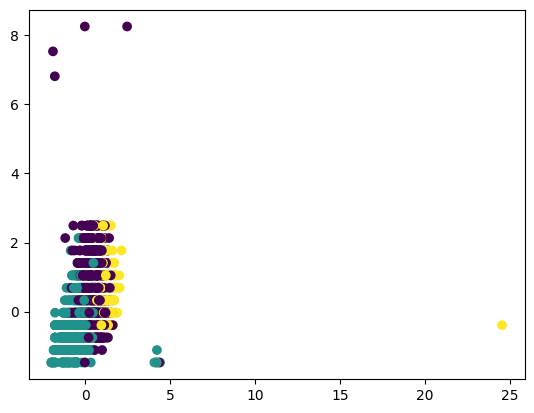

In [169]:
plt.scatter(X_scaled['Income'], X_scaled['NumWebPurchases'], c=labels)
plt.show()

In [170]:
px.scatter_3d(X_scaled, x='Income', y='NumWebPurchases', z='NumWebPurchases', color=labels)

До масштабування даних кластери виглядали якось більше лінійно, був чіткий поділ по Income. Це напевно через високі значення доходу порівняно з іншими ознаками. Після масштабування виглядає так, що вплив ознак став більш збалансованим.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

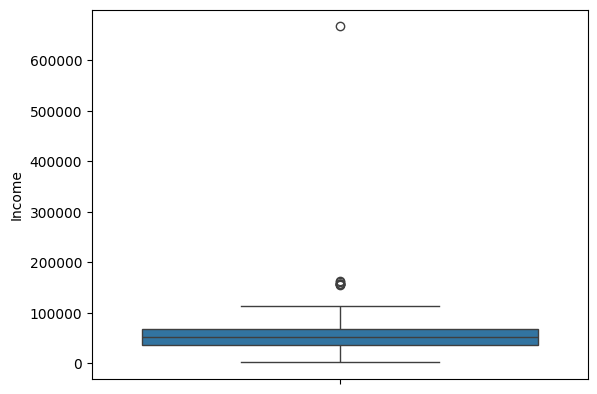

In [171]:
sns.boxplot(X.Income)
plt.show()

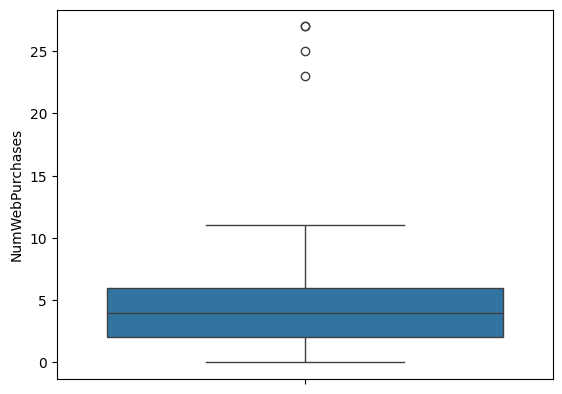

In [172]:
sns.boxplot(X.NumWebPurchases)
plt.show()

In [173]:
def replace_outliers_with_median(df, columns):
    df_copy = df.copy()
    for col in columns:
      Q1 = df_copy[col].quantile(0.25)
      Q3 = df_copy[col].quantile(0.75)
      IQR = Q3 - Q1

      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR

      median_value = df_copy[col].median()

      outliers_mask = (df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)
      df_copy.loc[outliers_mask, col] = median_value

    return df_copy


In [174]:
columns_to_filter = ['Income', 'NumWebPurchases']

In [175]:
X_clean = replace_outliers_with_median(X, columns_to_filter)

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

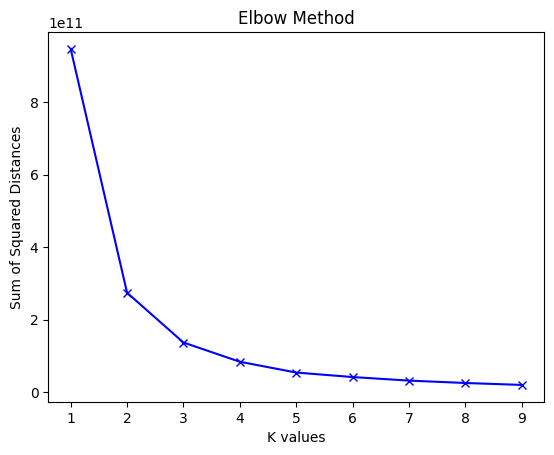

In [176]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_clean)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [177]:
kmeans = KMeans(n_clusters=4, random_state=17)

kmeans.fit(X_clean)

labels = kmeans.predict(X_clean)

silhouette = metrics.silhouette_score(X_clean, labels, metric='euclidean')

print(silhouette)

0.533777237190939


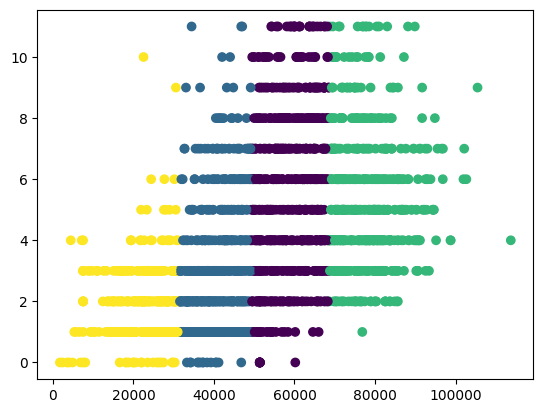

In [178]:
plt.scatter(X_clean['Income'], X_clean['NumWebPurchases'], c=labels)
plt.show()

In [179]:
px.scatter_3d(X_clean, x='Income', y='NumWebPurchases', z='NumWebPurchases', color=labels)

Видалення викидів зробило дані чистішими, але як і в першому випадку тут видно чіткий розподіл по доходу

In [180]:
X_clean_scaled = scaler.fit_transform(X_clean)
X_clean_scaled = pd.DataFrame(X_clean_scaled, columns=X_clean.columns)

In [181]:
kmeans = KMeans(n_clusters=4, random_state=17)

kmeans.fit(X_clean_scaled)

labels = kmeans.predict(X_clean_scaled)

silhouette = metrics.silhouette_score(X_clean_scaled, labels, metric='euclidean')

print(silhouette)

0.10444911768275207


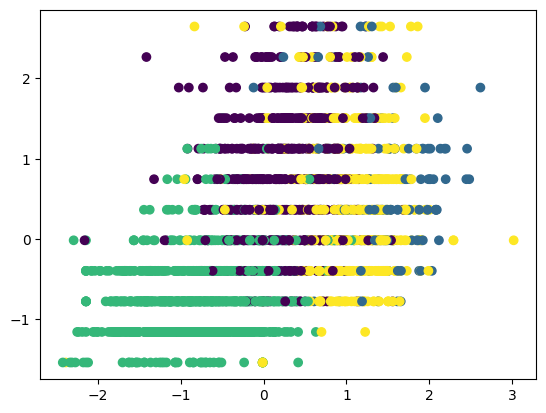

In [182]:
plt.scatter(X_clean_scaled['Income'], X_clean_scaled['NumWebPurchases'], c=labels)
plt.show()

In [183]:
px.scatter_3d(X_clean, x='Income', y='NumWebPurchases', z='NumWebPurchases', color=labels)

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [184]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

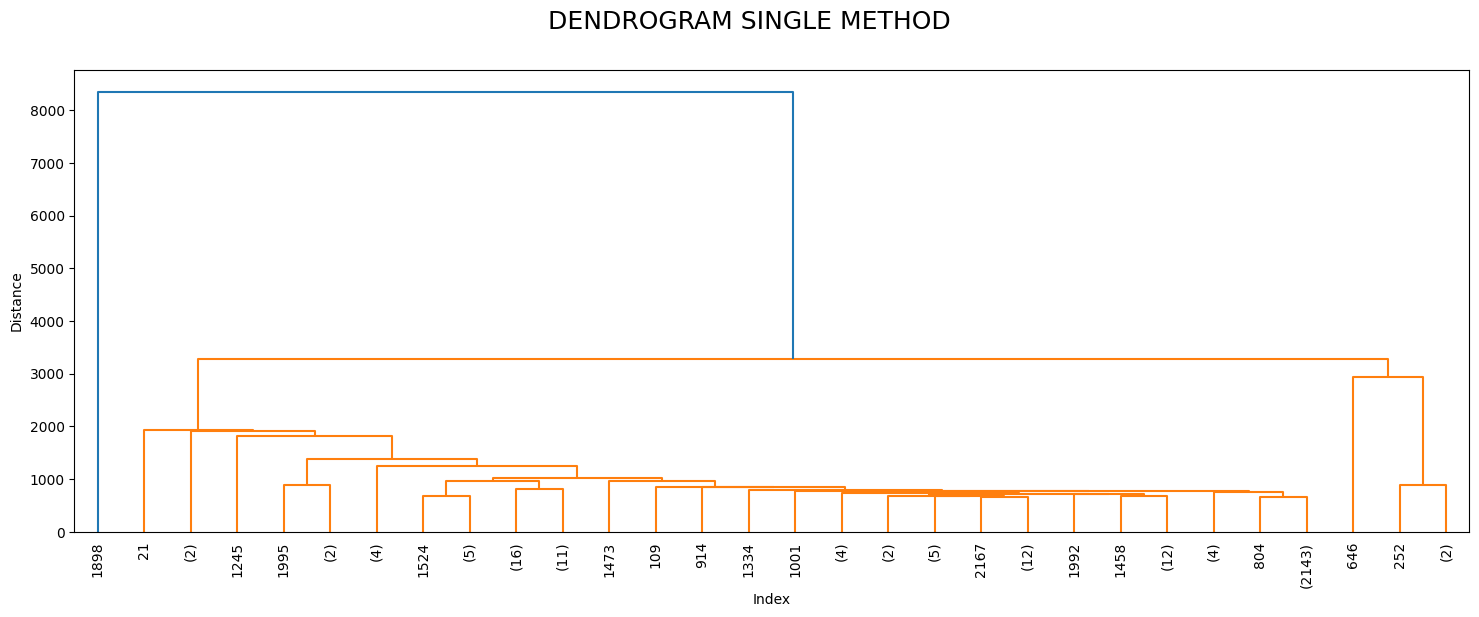

In [185]:
dist_sin = linkage(X_clean, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [186]:
X_clean['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_clean['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

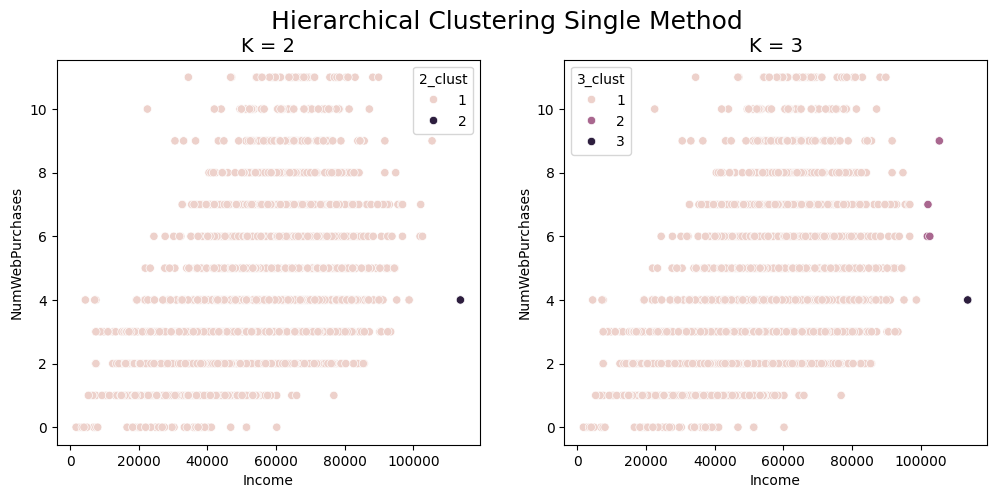

In [187]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Hierarchical Clustering Single Method", fontsize=18)

axes[0].set_title("K = 2", fontsize=14)
sns.scatterplot(x="Income", y="NumWebPurchases", data=X_clean, hue="2_clust", ax=axes[0])

axes[1].set_title("K = 3", fontsize=14)
sns.scatterplot(x="Income", y="NumWebPurchases", data=X_clean, hue="3_clust", ax=axes[1])

plt.show()

In [190]:
from sklearn.metrics import silhouette_score

In [195]:
silhouette_2 = silhouette_score(X_clean.drop(['2_clust', '3_clust'], axis=1), X_clean['2_clust'])

silhouette_3 = silhouette_score(X_clean.drop(['2_clust', '3_clust'], axis=1), X_clean['3_clust'])

silhouette_2, silhouette_3

(np.float64(0.558309401125515), np.float64(0.45173358903679894))

Виглядає, що ієрархічна кластеризація з методом "single linkage" погано впоралася.

При K = 2 алгоритм виділив лише один об'єкт в окремий кластер, а всі інші залишив у другому.

При K = 3 ситуація практично не змінилася. Алгоритм знову виділив той самий об'єкт в один кластер, додав ще декілька точок в інший кластер, а переважну більшість даних залишив у третьому.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

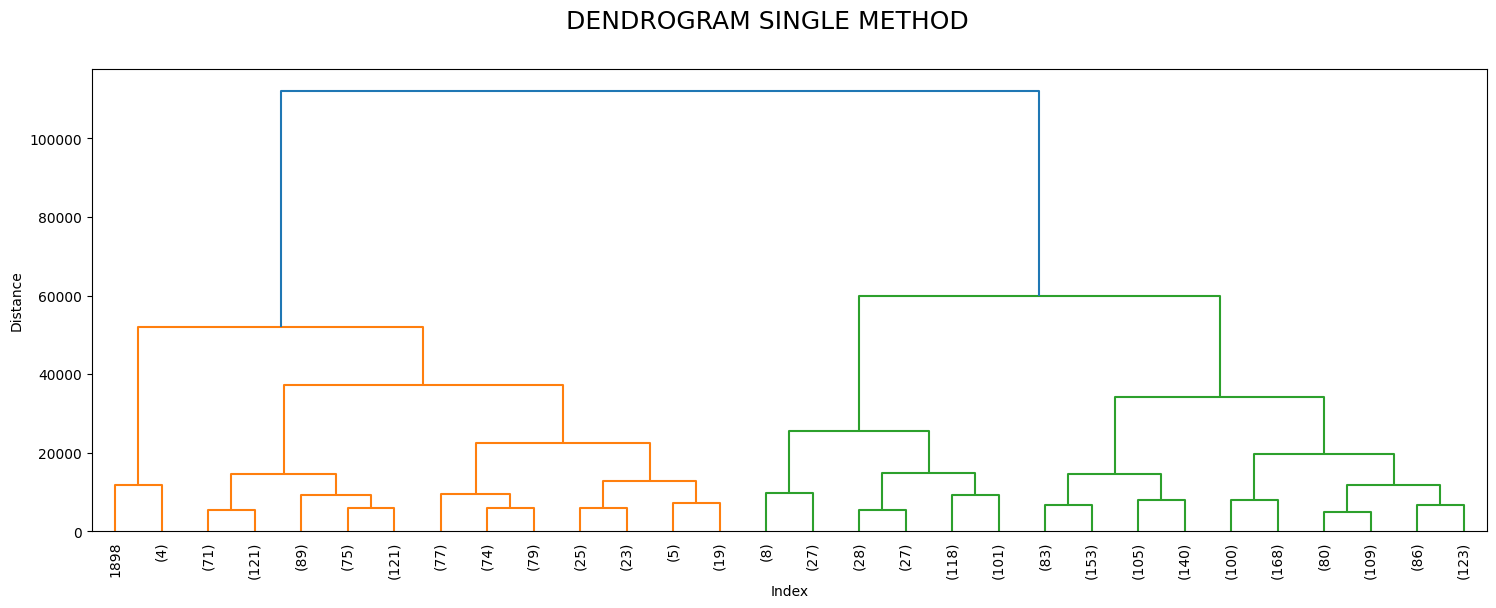

In [245]:
dist_sin = linkage(X_clean, method="complete")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [246]:
X_clean['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_clean['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

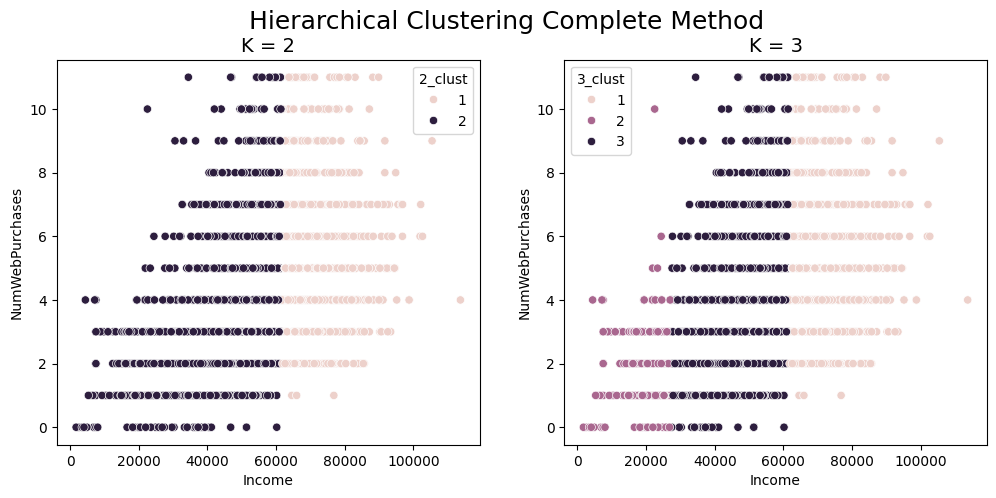

In [248]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Hierarchical Clustering Complete Method", fontsize=18)

axes[0].set_title("K = 2", fontsize=14)
sns.scatterplot(x="Income", y="NumWebPurchases", data=X_clean, hue="2_clust", ax=axes[0])

axes[1].set_title("K = 3", fontsize=14)
sns.scatterplot(x="Income", y="NumWebPurchases", data=X_clean, hue="3_clust", ax=axes[1])

plt.show()

In [249]:
silhouette_2 = silhouette_score(X_clean.drop(['2_clust', '3_clust'], axis=1), X_clean['2_clust'])

silhouette_3 = silhouette_score(X_clean.drop(['2_clust', '3_clust'], axis=1), X_clean['3_clust'])

silhouette_2, silhouette_3

(np.float64(0.5646261141711404), np.float64(0.5008903937697087))

Ієрархічна кластеризація з використанням Complete Method показала значно кращий результат. Алгоритм значно краще розділив дані на групи за рівнем доходу порівняно з попереднім варіантом.